# NB03: Phenotype Concordance

Do the new AI-generated annotations better explain experimental phenotypes than RAST/Bakta?

We use three experimentally-characterized gene sets as ground truth:
1. **Condition-specific genes** (2,034 genes with growth on 8 carbon sources)
2. **Quinate/aromatic network** (51 genes with cofitness-assigned subsystems)
3. **Respiratory chain** (62 genes with subsystem labels)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from collections import Counter

PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if 'adp1_annotation_reassessment' not in PROJECT_DIR:
    PROJECT_DIR = 'projects/adp1_annotation_reassessment'
REPO_ROOT = os.path.dirname(os.path.dirname(PROJECT_DIR)) if 'projects' in PROJECT_DIR else os.path.dirname(PROJECT_DIR)
if not os.path.exists(os.path.join(REPO_ROOT, 'projects')):
    REPO_ROOT = '.'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

master = pd.read_csv(os.path.join(PROJECT_DIR, 'data/master_annotation_table.csv'))
print(f'Master table: {len(master)} genes')

Master table: 5852 genes


## Load External Ground-Truth Data

In [2]:
# Condition-specific genes
cond_specific = pd.read_csv(os.path.join(REPO_ROOT, 'projects/adp1_deletion_phenotypes/data/condition_specific_genes.csv'))
print(f'Condition-specific genes: {len(cond_specific)}')

# Aromatic catabolism network
aromatic = pd.read_csv(os.path.join(REPO_ROOT, 'projects/aromatic_catabolism_network/data/final_network_model.csv'))
print(f'Aromatic network genes: {len(aromatic)}')
print(f'  Categories: {dict(aromatic["final_category"].value_counts())}')

# Respiratory chain
respiratory = pd.read_csv(os.path.join(REPO_ROOT, 'projects/respiratory_chain_wiring/data/respiratory_chain_genes.csv'))
print(f'Respiratory chain genes: {len(respiratory)}')
print(f'  Subsystems: {dict(respiratory["subsystem"].value_counts())}')

Condition-specific genes: 2034
Aromatic network genes: 51
  Categories: {'Complex I': np.int64(21), 'Aromatic pathway': np.int64(8), 'Iron acquisition': np.int64(7), 'Regulation': np.int64(6), 'Other': np.int64(6), 'PQQ biosynthesis': np.int64(2), 'Unknown': np.int64(1)}
Respiratory chain genes: 62
  Subsystems: {'Other respiratory': np.int64(20), 'Complex I (NDH-1)': np.int64(13), 'ATP synthase': np.int64(9), 'NADH-flavin OR': np.int64(5), 'Cyt bd oxidase': np.int64(5), 'Complex II (SDH)': np.int64(5), 'Cyt bo3 oxidase': np.int64(4), 'NDH-2': np.int64(1)}


## Part 1: Condition-Specific Genes

For genes showing condition specificity, does the annotation explain WHY they're specific to that condition?

In [3]:
# Merge condition specificity data with master table
cond_merged = cond_specific.merge(
    master[['feature_id', 'rast_function', 'bakta_function', 'agent_annotation',
            'rast_class', 'bakta_class', 'agent_class']],
    on='feature_id', how='left', suffixes=('_cond', '')
)
print(f'Condition-specific genes with annotations: {cond_merged["agent_annotation"].notna().sum()}/{len(cond_merged)}')

# Genes with high specificity (max_specificity > 1.5 from condition_specific_genes)
highly_specific = cond_merged[cond_merged['max_specificity'] > 1.5].copy()
print(f'Highly condition-specific genes (specificity > 1.5): {len(highly_specific)}')
print(f'  Most specific conditions: {dict(highly_specific["most_specific_condition"].value_counts())}')

Condition-specific genes with annotations: 1863/2034
Highly condition-specific genes (specificity > 1.5): 273
  Most specific conditions: {'urea': np.int64(62), 'asparagine': np.int64(46), 'glucose': np.int64(38), 'glucarate': np.int64(30), 'butanediol': np.int64(27), 'quinate': np.int64(27), 'lactate': np.int64(23), 'acetate': np.int64(20)}


In [4]:
# Define condition-relevant keywords for each carbon source
CONDITION_KEYWORDS = {
    'quinate': ['quinate', 'quinic', 'shikimate', 'protocatechuate', 'catechol', 'aromatic',
                'benzoate', 'vanillate', 'ferulate', 'hydroxybenzoate', 'dioxygenase',
                'decarboxylase', 'muconate', 'pcab', 'pcac', 'pcad', 'pcah', 'pcai', 'pcaj', 'pcak',
                'qui', 'pob', 'cat', 'ben', 'hca', 'van'],
    'acetate': ['acetate', 'acetyl', 'acyl', 'coa', 'glyoxylate', 'isocitrate', 'lyase',
                'malate', 'synthase', 'acs', 'aceA', 'aceB', 'ack', 'pta'],
    'glucarate': ['glucarate', 'galactarate', 'glucuronate', 'galacturonate', 'uronate',
                  'aldehyde', 'dehydratase', 'gudD', 'garD', 'garL', 'garR',
                  'sugar', 'acid'],
    'asparagine': ['asparagine', 'aspartate', 'asparaginase', 'amino', 'transaminas',
                   'glutamate', 'glutamine', 'nitrogen', 'ansA', 'ansB', 'aspA'],
    'glucose': ['glucose', 'gluconate', 'glycolysis', 'entner', 'doudoroff',
                'phosphogluconate', 'hexose', 'sugar', 'phosphotransferase',
                'gcd', 'gnuK', 'zwf', 'edd', 'eda'],
    'lactate': ['lactate', 'pyruvate', 'dehydrogenase', 'lldD', 'lldP', 'dld',
                'oxidoreductase', 'electron'],
    'butanediol': ['butanediol', 'butanol', 'acetoin', 'alcohol', 'dehydrogenase',
                   'oxidoreductase', 'budA', 'budB', 'budC', 'acoA', 'acoB'],
    'urea': ['urea', 'urease', 'nitrogen', 'ammonium', 'glutamine', 'glutamate',
             'ureA', 'ureB', 'ureC', 'ureD', 'ureE', 'ureF', 'ureG']
}

def annotation_concordant(annotation, condition):
    """Check if an annotation contains keywords relevant to the growth condition."""
    if pd.isna(annotation) or condition not in CONDITION_KEYWORDS:
        return False
    ann_lower = str(annotation).lower()
    return any(kw in ann_lower for kw in CONDITION_KEYWORDS[condition])

# Score concordance for each annotation source
for source, col in [('RAST', 'rast_function'), ('Bakta', 'bakta_function'), ('Agent', 'agent_annotation')]:
    highly_specific[f'{source}_concordant'] = highly_specific.apply(
        lambda row: annotation_concordant(row[col], row['most_specific_condition']), axis=1
    )

# Summary
for source in ['RAST', 'Bakta', 'Agent']:
    n_concordant = highly_specific[f'{source}_concordant'].sum()
    total = len(highly_specific)
    print(f'{source}: {n_concordant}/{total} ({n_concordant/total*100:.1f}%) highly-specific genes have concordant annotation')

RAST: 39/273 (14.3%) highly-specific genes have concordant annotation
Bakta: 41/273 (15.0%) highly-specific genes have concordant annotation
Agent: 61/273 (22.3%) highly-specific genes have concordant annotation


In [5]:
# Per-condition breakdown
concordance_by_condition = []
for condition in CONDITION_KEYWORDS.keys():
    subset = highly_specific[highly_specific['most_specific_condition'] == condition]
    if len(subset) == 0:
        continue
    row = {'Condition': condition, 'N': len(subset)}
    for source in ['RAST', 'Bakta', 'Agent']:
        n = subset[f'{source}_concordant'].sum()
        row[f'{source}_concordant'] = n
        row[f'{source}_rate'] = n / len(subset)
    concordance_by_condition.append(row)

concordance_df = pd.DataFrame(concordance_by_condition)
print(concordance_df[['Condition', 'N', 'RAST_concordant', 'Bakta_concordant', 'Agent_concordant']].to_string(index=False))

 Condition  N  RAST_concordant  Bakta_concordant  Agent_concordant
   quinate 27               17                18                21
   acetate 20                2                 0                 6
 glucarate 30                2                 5                 9
asparagine 46                2                 2                 3
   glucose 38                3                 3                 4
   lactate 23                2                 1                 3
butanediol 27                3                 4                 6
      urea 62                8                 8                 9


In [6]:
# Show examples where agent is concordant but RAST is not
agent_wins = highly_specific[
    highly_specific['Agent_concordant'] & ~highly_specific['RAST_concordant']
].head(8)

print(f'Agent concordant but RAST not ({len(highly_specific[highly_specific["Agent_concordant"] & ~highly_specific["RAST_concordant"]])} genes):')
print('=' * 120)
for _, row in agent_wins.iterrows():
    print(f'  {row["feature_id"]} — specific to: {row["most_specific_condition"]} (specificity={row["max_specificity"]:.2f})')
    print(f'    RAST:  {row["rast_function"]}')
    agent_short = str(row['agent_annotation'])[:140]
    print(f'    Agent: {agent_short}' + ('...' if len(str(row['agent_annotation'])) > 140 else ''))
    print()

Agent concordant but RAST not (27 genes):
  ACIAD_RS16605 — specific to: urea (specificity=4.01)
    RAST:  hypothetical protein
    Agent: Predicted GNAT-like acyl-CoA–dependent N-acyltransferase that acetylates amine-containing metabolites, impacting carbon/nitrogen utilization...

  ACIAD_RS16065 — specific to: lactate (specificity=1.55)
    RAST:  DUF445 domain-containing protein
    Agent: DUF445 family accessory protein implicated in purine degradation, likely supporting xanthine dehydrogenase function during utilization of pu...

  ACIAD_RS14090 — specific to: urea (specificity=2.75)
    RAST:  Ribosome small subunit biogenesis RbfA-release protein RsgA
    Agent: Urease accessory GTPase (UreG-family), required for urease maturation/activation and growth on urea and related ureides as nitrogen sources.

  ACIAD_RS12490 — specific to: lactate (specificity=1.73)
    RAST:  Methylisocitrate lyase (EC 4.1.3.30)
    Agent: Predicted 2-methylisocitrate lyase (PrpB), a pyruvate kinase-

## Part 2: Quinate/Aromatic Network Validation

The aromatic catabolism network has 51 genes assigned to subsystems via cofitness. Can the agent independently confirm those assignments?

In [7]:
# Merge aromatic network with master table
aromatic_merged = aromatic.merge(
    master[['feature_id', 'rast_function', 'bakta_function', 'agent_annotation',
            'rast_class', 'bakta_class', 'agent_class']],
    on='feature_id', how='left', suffixes=('_aro', '')
)
print(f'Aromatic genes with agent annotation: {aromatic_merged["agent_annotation"].notna().sum()}/{len(aromatic_merged)}')

# Keywords that indicate aromatic catabolism
AROMATIC_KEYWORDS = ['aromatic', 'catechol', 'protocatechuate', 'benzoate', 'quinate', 'quinic',
                     'vanillate', 'ferulate', 'muconate', 'dioxygenase', 'monooxygenase',
                     'hydroxylase', 'decarboxylase', 'pcab', 'pcac', 'pcad', 'pcah',
                     'ben', 'cat', 'van', 'pob', 'hca', 'sal', 'are', 'qui',
                     'shikimate', 'chorismate', 'anthranilate']

def is_aromatic_annotation(ann):
    if pd.isna(ann): return False
    ann_lower = str(ann).lower()
    return any(kw in ann_lower for kw in AROMATIC_KEYWORDS)

aromatic_pathway = aromatic_merged[aromatic_merged['final_category'] == 'Aromatic pathway']
print(f'\nAromatic pathway genes: {len(aromatic_pathway)}')

for source, col in [('RAST', 'rast_function'), ('Bakta', 'bakta_function'), ('Agent', 'agent_annotation')]:
    n_correct = aromatic_pathway[col].apply(is_aromatic_annotation).sum()
    print(f'  {source} correctly identifies aromatic function: {n_correct}/{len(aromatic_pathway)} ({n_correct/len(aromatic_pathway)*100:.1f}%)')

Aromatic genes with agent annotation: 50/51

Aromatic pathway genes: 8
  RAST correctly identifies aromatic function: 6/8 (75.0%)
  Bakta correctly identifies aromatic function: 6/8 (75.0%)
  Agent correctly identifies aromatic function: 7/8 (87.5%)


In [8]:
# Focus on Unknown genes in the aromatic network — can agent identify them?
unknowns = aromatic_merged[aromatic_merged['final_category'] == 'Unknown']
print(f'Unknown genes in aromatic network: {len(unknowns)}')
print()
for _, row in unknowns.iterrows():
    print(f'  {row["feature_id"]} ({row["old_locus_tag"]})')
    print(f'    RAST:  {row["rast_function"]}')
    print(f'    Bakta: {row["bakta_function"]}')
    agent_short = str(row['agent_annotation'])[:140]
    print(f'    Agent: {agent_short}' + ('...' if len(str(row['agent_annotation'])) > 140 else ''))
    print(f'    Cofitness assignment: {row.get("cofitness_assignment", "N/A")} (r={row.get("cofitness_r", "N/A")})')
    print()

Unknown genes in aromatic network: 1

  ACIAD_RS11535 (ACIAD2540)
    RAST:  hypothetical protein
    Bakta: Porin
    Agent: nan
    Cofitness assignment: nan (r=nan)



## Part 3: Respiratory Chain Validation

For 62 characterized respiratory genes, does the agent correctly place them in their subsystem?

In [9]:
# Merge respiratory chain with master table
resp_merged = respiratory.merge(
    master[['feature_id', 'rast_function', 'bakta_function', 'agent_annotation',
            'rast_class', 'bakta_class', 'agent_class']],
    on='feature_id', how='left', suffixes=('_resp', '')
)
print(f'Respiratory genes with agent annotation: {resp_merged["agent_annotation"].notna().sum()}/{len(resp_merged)}')

# Subsystem-specific keywords
RESP_KEYWORDS = {
    'ATP synthase': ['atp', 'synthase', 'atpase', 'f0', 'f1', 'fo'],
    'Complex I (NDH-1)': ['nadh', 'nuo', 'complex i', 'ndh', 'ubiquinone'],
    'Complex II (SDH)': ['succinate', 'sdh', 'fumarate', 'complex ii'],
    'Cyt bd oxidase': ['cytochrome', 'bd', 'oxidase', 'cyd'],
    'Cyt bo3 oxidase': ['cytochrome', 'bo3', 'oxidase', 'cyo'],
    'NADH-flavin OR': ['nadh', 'flavin', 'oxidoreductase', 'ndh'],
    'NDH-2': ['nadh', 'ndh', 'dehydrogenase'],
    'Other respiratory': ['electron', 'respiratory', 'quinone', 'ubiquinone', 'menaquinone']
}

def annotation_matches_subsystem(ann, subsystem):
    if pd.isna(ann) or subsystem not in RESP_KEYWORDS:
        return False
    ann_lower = str(ann).lower()
    keywords = RESP_KEYWORDS[subsystem]
    return sum(1 for kw in keywords if kw in ann_lower) >= 1

# Score per subsystem
subsystem_results = []
for subsystem in resp_merged['subsystem'].unique():
    subset = resp_merged[resp_merged['subsystem'] == subsystem]
    row = {'Subsystem': subsystem, 'N': len(subset)}
    for source, col in [('RAST', 'rast_function'), ('Bakta', 'bakta_function'), ('Agent', 'agent_annotation')]:
        n_match = subset.apply(lambda r: annotation_matches_subsystem(r[col], subsystem), axis=1).sum()
        row[f'{source}_match'] = n_match
    subsystem_results.append(row)

subsystem_df = pd.DataFrame(subsystem_results)
print(subsystem_df.to_string(index=False))

# Overall accuracy
for source, col in [('RAST', 'rast_function'), ('Bakta', 'bakta_function'), ('Agent', 'agent_annotation')]:
    total_match = resp_merged.apply(
        lambda r: annotation_matches_subsystem(r[col], r['subsystem']), axis=1
    ).sum()
    print(f'\n{source} overall respiratory accuracy: {total_match}/{len(resp_merged)} ({total_match/len(resp_merged)*100:.1f}%)')

Respiratory genes with agent annotation: 62/62
        Subsystem  N  RAST_match  Bakta_match  Agent_match
     ATP synthase  9           9            9            9
   NADH-flavin OR  5           5            2            5
Complex I (NDH-1) 13          13           13           10
Other respiratory 20           4            4            6
   Cyt bd oxidase  5           5            5            4
  Cyt bo3 oxidase  4           4            4            3
 Complex II (SDH)  5           5            5            5
            NDH-2  1           1            1            1

RAST overall respiratory accuracy: 46/62 (74.2%)

Bakta overall respiratory accuracy: 43/62 (69.4%)

Agent overall respiratory accuracy: 43/62 (69.4%)


## Summary Figure: Phenotype Concordance by Annotation Source

Source  Condition specificity  Aromatic network  Respiratory chain
  RAST              14.285714              75.0          74.193548
 Bakta              15.018315              75.0          69.354839
 Agent              22.344322              87.5          69.354839


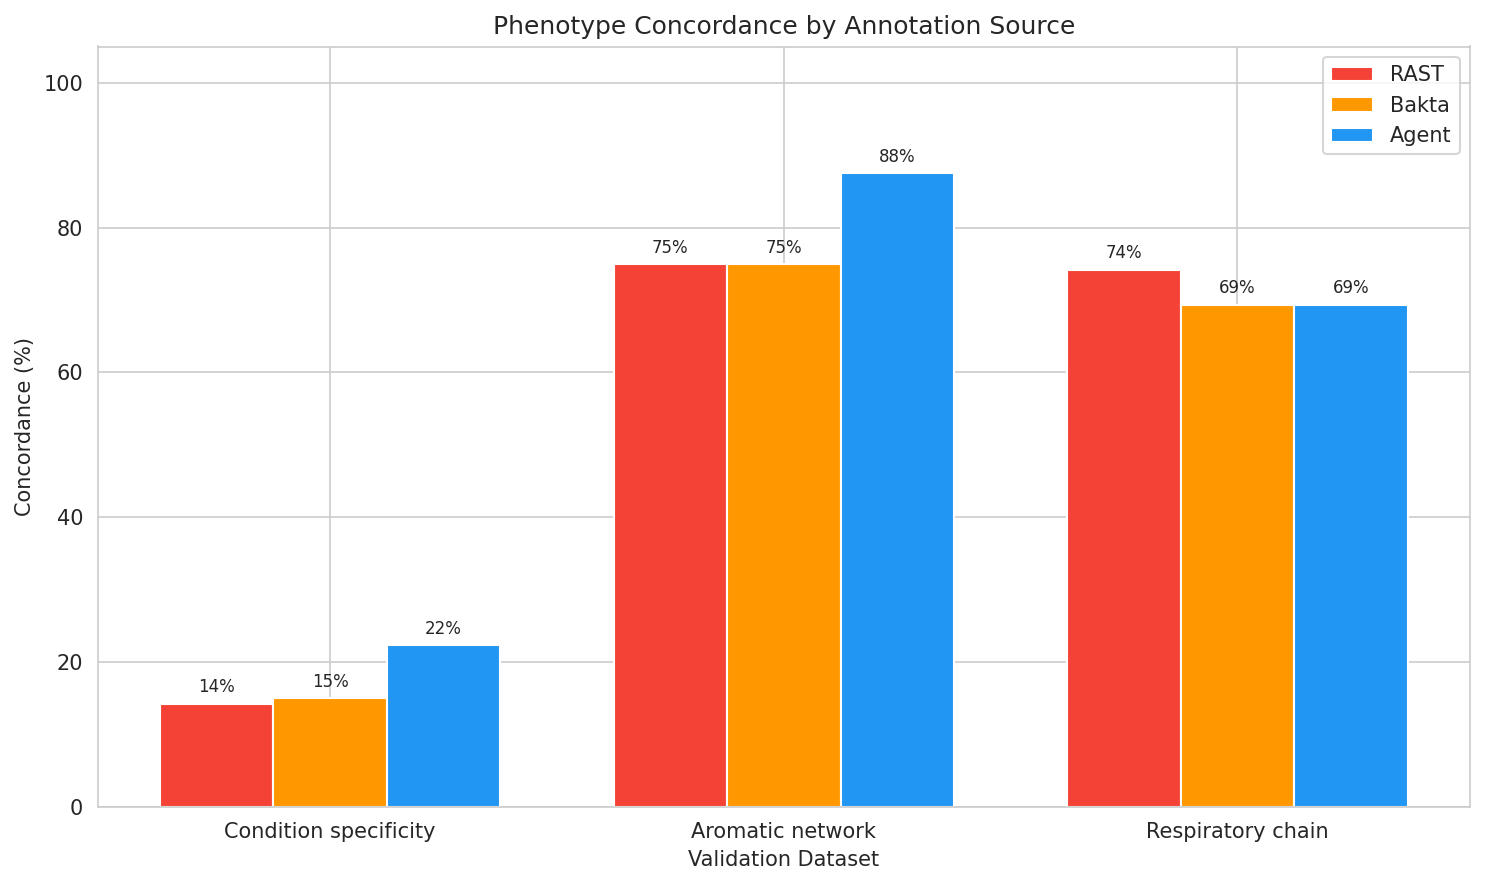

In [10]:
# Compute overall concordance scores
# 1. Condition specificity concordance (% of highly-specific genes with concordant annotation)
# 2. Aromatic network accuracy (% of aromatic pathway genes correctly identified)
# 3. Respiratory chain accuracy (% of respiratory genes with subsystem-matching annotation)

summary_data = []
for source, col in [('RAST', 'rast_function'), ('Bakta', 'bakta_function'), ('Agent', 'agent_annotation')]:
    cond_conc = highly_specific[f'{source}_concordant'].mean() * 100
    aro_conc = aromatic_pathway[col].apply(is_aromatic_annotation).mean() * 100
    resp_conc = resp_merged.apply(
        lambda r: annotation_matches_subsystem(r[col], r['subsystem']), axis=1
    ).mean() * 100
    summary_data.append({
        'Source': source,
        'Condition specificity': cond_conc,
        'Aromatic network': aro_conc,
        'Respiratory chain': resp_conc
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
width = 0.25
metrics = ['Condition specificity', 'Aromatic network', 'Respiratory chain']
colors = {'RAST': '#F44336', 'Bakta': '#FF9800', 'Agent': '#2196F3'}

for i, (_, row) in enumerate(summary_df.iterrows()):
    bars = ax.bar(x + i * width, [row[m] for m in metrics], width,
                  label=row['Source'], color=colors[row['Source']])
    for bar, metric in zip(bars, metrics):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{row[metric]:.0f}%', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Validation Dataset')
ax.set_ylabel('Concordance (%)')
ax.set_title('Phenotype Concordance by Annotation Source')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures/phenotype_concordance.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Annotation status of condition-specific genes
# How many highly-specific genes are hypothetical in each source?
print('Annotation status of highly condition-specific genes:')
for source in ['rast_class', 'bakta_class', 'agent_class']:
    print(f'\n{source}:')
    print(highly_specific[source].value_counts())

Annotation status of highly condition-specific genes:

rast_class:
rast_class
specific        240
hypothetical     31
missing           2
Name: count, dtype: int64

bakta_class:
bakta_class
specific        257
hypothetical     14
missing           2
Name: count, dtype: int64

agent_class:
agent_class
specific        258
missing          13
hypothetical      2
Name: count, dtype: int64
